In [3]:
from lib import DoublePendulum, get_lyapunov, compute_points

In [4]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
import argparse
import numpy as np
import matplotlib.pyplot as plt

## Generate heatmap

In [5]:
res = 360
total = res**2

In [6]:
theta1_vals = np.linspace(0,360,res)
theta2_vals = theta1_vals.copy()

In [7]:
CHECKPOINTS = [5, 10]
epsilon = 1e-6
dt = 0.01

In [8]:
heats = {t: np.full((res, res), np.nan) for t in CHECKPOINTS}

In [9]:
with ProcessPoolExecutor(max_workers=20) as ex:
    futures = [ex.submit(compute_points, i, j, t1, t2, CHECKPOINTS, dt, epsilon)
               for i, t1 in enumerate(theta1_vals)
               for j, t2 in enumerate(theta2_vals)]
    
    done = 0
    for f in as_completed(futures):
        i, j, lyap_dict = f.result()
        for t, lyap in lyap_dict.items():
            heats[t][j, i] = lyap
        done += 1
        if done % max(1, total // 20) == 0:
            print(f"progress: {done}/{total} ({done/total*100:.1f}%)")

progress: 6480/129600 (5.0%)
progress: 12960/129600 (10.0%)
progress: 19440/129600 (15.0%)
progress: 25920/129600 (20.0%)
progress: 32400/129600 (25.0%)
progress: 38880/129600 (30.0%)
progress: 45360/129600 (35.0%)
progress: 51840/129600 (40.0%)
progress: 58320/129600 (45.0%)
progress: 64800/129600 (50.0%)
progress: 71280/129600 (55.0%)
progress: 77760/129600 (60.0%)
progress: 84240/129600 (65.0%)
progress: 90720/129600 (70.0%)
progress: 97200/129600 (75.0%)
progress: 103680/129600 (80.0%)
progress: 110160/129600 (85.0%)
progress: 116640/129600 (90.0%)
progress: 123120/129600 (95.0%)
progress: 129600/129600 (100.0%)


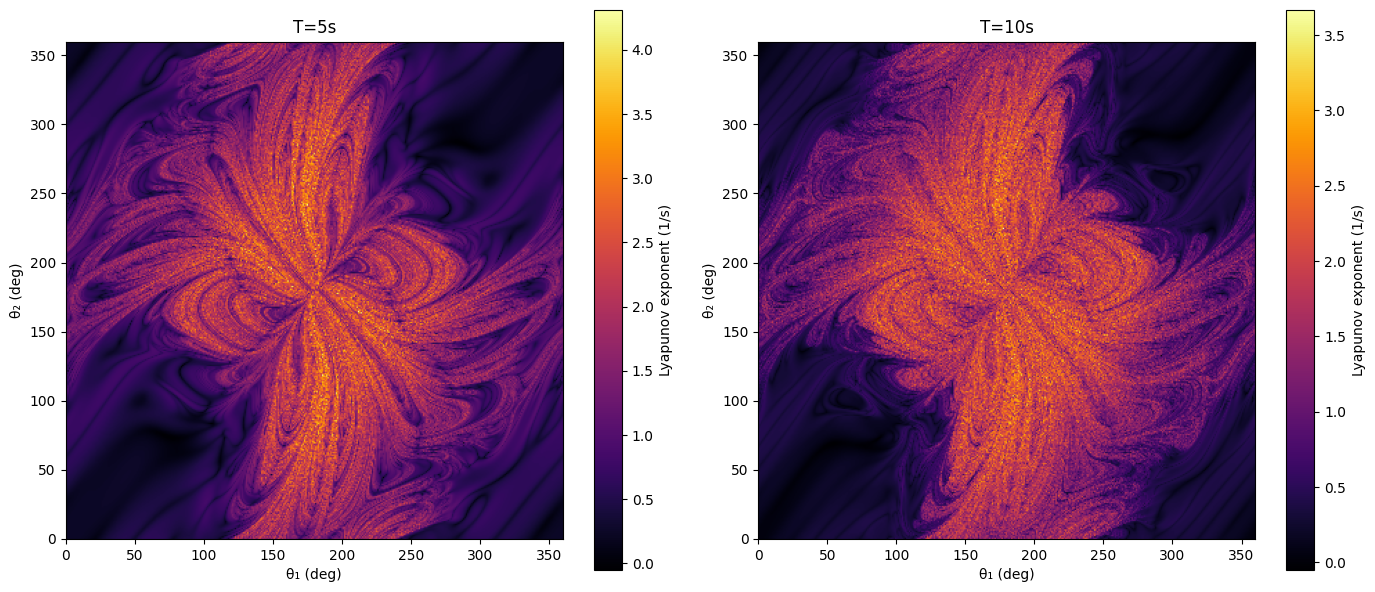

In [10]:
fig, axes = plt.subplots(1, len(CHECKPOINTS), figsize=(7 * len(CHECKPOINTS), 6))
for ax, t in zip(axes, CHECKPOINTS):
    im = ax.imshow(
        heats[t],
        extent=[0, 360, 0, 360],  # [left, right, bottom, top]
        origin='lower',
        cmap='inferno'
    )
    ax.set_title(f'T={t}s')
    ax.set_xlabel('θ₁ (deg)')
    ax.set_ylabel('θ₂ (deg)')
    fig.colorbar(im, ax=ax, label='Lyapunov exponent (1/s)')

fig.tight_layout()
plt.show()